# Мульти-ответные запросы — 3-way гибрид

44% запросов calibration имеют **несколько правильных статей** (`n_gt≥2`), а MAP@10
вознаграждает за то, чтобы поднять наверх **все** релевантные, не только одну.
Разбираем именно это:

1. **Capture rate** — сколько из правильных статей реально попадает в топ-10.
2. **Где теряется «вторая/третья»** — она чуть ниже отсечки (ранжирование) или
   вообще глубоко (поиск)?
3. **Помог бы граф ссылок?** — является ли потерянная статья соседом по ссылкам
   какой-то из уже найденных (тогда её можно «добрать» расширением по графу).

> Данные из кеша (без torch): `hybrid_calib_preds50.pkl`, `model_rankings.pkl`.

In [1]:
import sys, pickle
sys.path.insert(0, "..")
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import EMB_CACHE
from src.data import load_articles, load_calibration, build_truth

sns.set_theme(style="whitegrid"); plt.rcParams["font.family"] = "DejaVu Sans"

articles = load_articles()
calibration = load_calibration()
truth = build_truth(calibration)
id2title = dict(zip(articles["article_id"], articles["title"]))
q2text = dict(zip(calibration["query_id"], calibration["query_text"]))

preds50 = {int(k): v for k, v in pickle.load(open(EMB_CACHE/"hybrid_calib_preds50.pkl","rb"))["preds50"].items()}
rankings = pickle.load(open(EMB_CACHE/"model_rankings.pkl","rb"))     # rankings[model][qid][aid]=rank
hyb_rank = rankings["hybrid"]

# граф ссылок (неориентированный, внутри корпуса)
all_ids = set(articles["article_id"])
neigh = defaultdict(set)
for aid, links in zip(articles["article_id"], articles["linked_ids"]):
    for b in set(links) & all_ids:
        if b != aid:
            neigh[aid].add(b); neigh[b].add(aid)

K = 10
multi = [q for q in truth if len(truth[q]) >= 2]
print(f"всего запросов: {len(truth)} | мульти-ответных (n_gt>=2): {len(multi)}")

всего запросов: 500 | мульти-ответных (n_gt>=2): 221


## 1. Capture rate — ловим ли ВСЕ правильные статьи в топ-10

In [2]:
rows = []
for q in truth:
    gt = truth[q]; top = set(preds50[q][:K])
    rows.append({"query_id": q, "n_gt": len(gt),
                 "captured": len(gt & top), "missed": len(gt - top)})
cap = pd.DataFrame(rows)
cap["capture_rate"] = cap["captured"] / cap["n_gt"]

print("Средняя доля пойманных правильных статей (capture@10):")
print(f"  все запросы:       {cap['capture_rate'].mean():.3f}")
print(f"  одноответные:      {cap.loc[cap.n_gt==1,'capture_rate'].mean():.3f}")
print(f"  мульти (n_gt>=2):  {cap.loc[cap.n_gt>=2,'capture_rate'].mean():.3f}")
print(f"\nПолностью пойманы (все gt в топ-10): "
      f"{(cap['missed']==0).mean()*100:.1f}% запросов "
      f"| среди мульти: {(cap.loc[cap.n_gt>=2,'missed']==0).mean()*100:.1f}%")

Средняя доля пойманных правильных статей (capture@10):
  все запросы:       0.844
  одноответные:      0.882
  мульти (n_gt>=2):  0.796

Полностью пойманы (все gt в топ-10): 77.6% запросов | среди мульти: 64.3%


Строки — n_gt, столбцы — сколько поймали в топ-10:
captured   0    1    2   3
n_gt                      
1         33  246    0   0
2         11   47  124   0
3          2    6   12  18
4          0    0    1   0


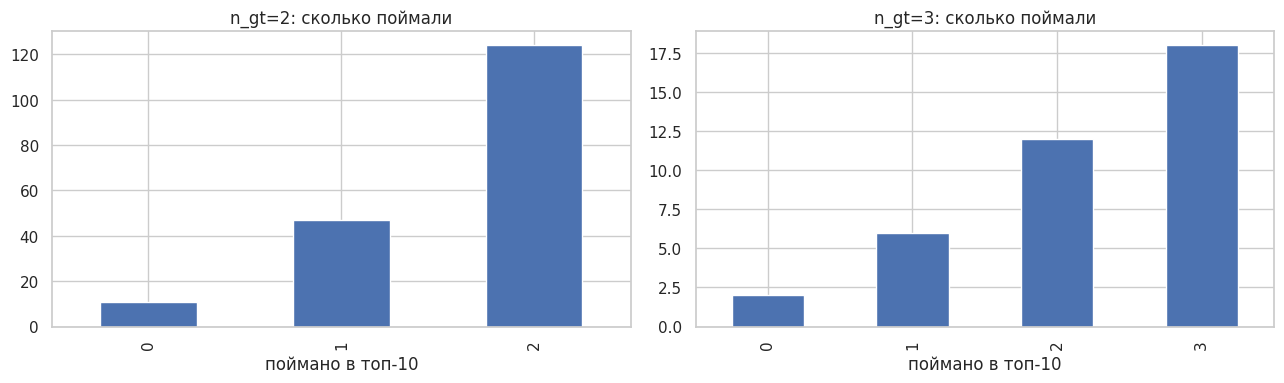

In [3]:
# распределение: при n_gt=k сколько статей реально поймали
ct = pd.crosstab(cap["n_gt"], cap["captured"])
print("Строки — n_gt, столбцы — сколько поймали в топ-10:")
print(ct)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for k in (2, 3):
    sub = cap[cap.n_gt == k]
    sub["captured"].value_counts().sort_index().plot.bar(
        ax=ax[0] if k == 2 else ax[1], color="#4C72B0")
    (ax[0] if k == 2 else ax[1]).set_title(f"n_gt={k}: сколько поймали")
    (ax[0] if k == 2 else ax[1]).set_xlabel("поймано в топ-10")
plt.tight_layout(); plt.show()

## 2. Где теряется «вторая/третья» статья

Для мульти-запросов смотрим на **пропущенные** правильные статьи: их ранг в полном
ранжировании гибрида — они сразу за отсечкой (ранжирование) или глубоко (поиск)?

всего пропущенных правильных статей (в мульти-запросах): 101
  ранг 11–15 (сразу за топ-10)         :  46 (45.5%)
  ранг 16–30                           :  26 (25.7%)
  ранг 31–50                           :  15 (14.9%)
  ранг >50 (глубокий промах поиска)    :  10 ( 9.9%)


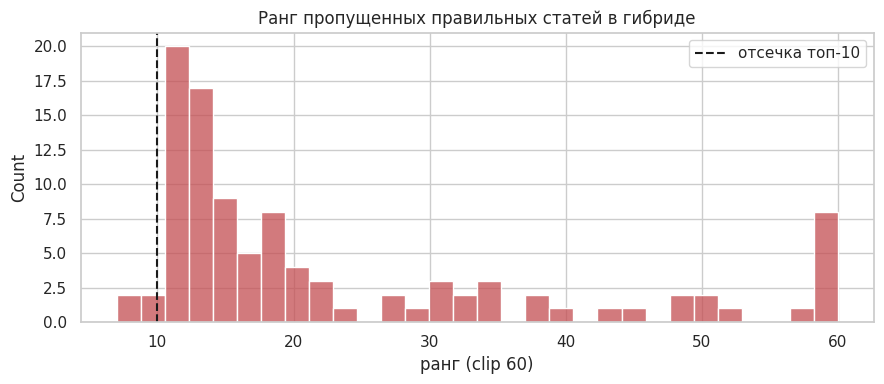

In [4]:
missed_ranks = []
for q in multi:
    for b in (truth[q] - set(preds50[q][:K])):
        missed_ranks.append(hyb_rank[q].get(b, 999))
missed_ranks = np.array(missed_ranks)

print(f"всего пропущенных правильных статей (в мульти-запросах): {len(missed_ranks)}")
for lo, hi, name in [(11,15,"11–15 (сразу за топ-10)"), (16,30,"16–30"),
                     (31,50,"31–50"), (51,10**9,">50 (глубокий промах поиска)")]:
    n = int(((missed_ranks>=lo)&(missed_ranks<=hi)).sum())
    print(f"  ранг {name:32s}: {n:3d} ({n/len(missed_ranks)*100:4.1f}%)")

plt.figure(figsize=(9,4))
sns.histplot(np.clip(missed_ranks, 0, 60), bins=30, color="#C44E52")
plt.axvline(K, color="k", ls="--", label="отсечка топ-10"); plt.legend()
plt.title("Ранг пропущенных правильных статей в гибриде"); plt.xlabel("ранг (clip 60)")
plt.tight_layout(); plt.show()

## 3. Помог бы граф ссылок для «добора» пропущенных?

Идея: если пропущенная правильная статья **связана ссылкой** с одной из статей,
которые мы уже вернули в топ-10, её можно добрать расширением по графу.

In [5]:
# сколько пропущенных правильных статей — соседи по графу для наших top-10
in_neigh_top10 = 0
in_neigh_captured_gt = 0
total_missed = 0
for q in multi:
    top = preds50[q][:K]
    hood_top = set().union(*[neigh[d] for d in top]) if top else set()
    captured_gt = truth[q] & set(top)
    hood_gt = set().union(*[neigh[d] for d in captured_gt]) if captured_gt else set()
    for b in (truth[q] - set(top)):
        total_missed += 1
        if b in hood_top: in_neigh_top10 += 1
        if b in hood_gt:  in_neigh_captured_gt += 1

print(f"пропущенных правильных статей всего: {total_missed}")
print(f"  из них — соседи по ссылкам любой из top-10:      {in_neigh_top10} "
      f"({in_neigh_top10/total_missed*100:.1f}%)")
print(f"  из них — соседи уже пойманной ПРАВИЛЬНОЙ статьи:  {in_neigh_captured_gt} "
      f"({in_neigh_captured_gt/total_missed*100:.1f}%)")
print("\n(это потолок: сколько пропущенных в принципе достижимо добором по графу)")

пропущенных правильных статей всего: 101
  из них — соседи по ссылкам любой из top-10:      63 (62.4%)
  из них — соседи уже пойманной ПРАВИЛЬНОЙ статьи:  23 (22.8%)

(это потолок: сколько пропущенных в принципе достижимо добором по графу)


In [6]:
# примеры: пропущенная правильная статья, связанная с пойманной правильной
print("Примеры, где граф мог бы добрать вторую статью:\n")
shown = 0
for q in multi:
    top = preds50[q][:K]; captured_gt = truth[q] & set(top)
    for b in (truth[q] - set(top)):
        linked_to = [g for g in captured_gt if b in neigh[g]]
        if linked_to:
            g = linked_to[0]
            print(f"[{q}] {q2text[q][:65]}")
            print(f"    поймана:   {g}:{id2title.get(g,'?')[:40]}")
            print(f"    пропущена: {b}:{id2title.get(b,'?')[:40]}  (ранг в гибриде {hyb_rank[q].get(b,'—')})")
            print()
            shown += 1; break
    if shown >= 6: break

Примеры, где граф мог бы добрать вторую статью:

[14] Добрый день! Прошу уточнить: подключил при продаже авито доставку
    поймана:   4234:Как продавать и покупать с доставкой
    пропущена: 1951:Кто оплачивает доставку и сколько она ст  (ранг в гибриде 14)

[29] Добрый вечер, не могу выложить авто, авто в собственности около д
    поймана:   2908:Нужно подтвердить, что вы собственник
    пропущена: 4307:Лимит бесплатных размещений  (ранг в гибриде 15)

[41] Прошу вернуть деньги.Я вам отправила чек.Вы обещали вернуть за не
    поймана:   4219:Покупателю
    пропущена: 4400:Покупателю — отказаться от товара или ве  (ранг в гибриде 22)

[89] Как активировать оплату после получения при оформлении
    поймана:   4219:Покупателю
    пропущена: 4234:Как продавать и покупать с доставкой  (ранг в гибриде 15)

[97] Я отказался от заказа, а деньги не пришли
    поймана:   4219:Покупателю
    пропущена: 4384:Баланс для покупок  (ранг в гибриде 39)

[103] здравствуйте !сделал заказ,вернул его,но 

## 4. Выводы

*(заполняется по числам выше)*

- **Capture rate** показывает, насколько «полны» наши ответы у мульти-запросов —
  главный резерв MAP@10, если он низкий.
- Если пропущенные статьи в основном на рангах **11–30** → это ранжирование
  (reranker / веса), а не поиск.
- Доля пропущенных, достижимых **добором по графу ссылок**, оценивает потолок этой
  идеи: стоит ли реализовывать graph-expansion.